# PHẦN 3 - DATA VISUALIZATION
Mục tiêu:
- Vẽ doanh thu theo tháng (Line chart)
- Vẽ doanh thu theo khu vực (Bar chart)
- Vẽ tỷ lệ doanh thu theo Category (Pie chart)
- Vẽ mối quan hệ giữa Sales và Profit (Scatter plot)

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tăng độ đẹp cho biểu đồ
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Load Data

In [2]:
df = pd.read_csv("orders_cleaned.csv")
df["OrderDate"] = pd.to_datetime(df["OrderDate"], errors="coerce")

# Nếu file chưa có cột Month thì tạo lại
if "Month" not in df.columns:
    df["Month"] = df["OrderDate"].dt.month

df.head()

,OrderID,OrderDate,Region,Category,ProductName,Sales,Quantity,Profit,CustomerType,Month
0,1000,2023-04-13,West,Technology,Phone,199.78,8,19.84,Consumer,4
1,1001,2023-03-29,East,Office Supplies,Pen,234.00,7,-40.00,Corporate,3
2,1002,2023-05-30,East,Office Supplies,Notebook,180.18,8,27.75,Consumer,5
3,1003,2023-10-21,South,Technology,Monitor,47.08,8,10.18,Corporate,10
4,1004,2023-11-10,West,Technology,Monitor,20.37,5,2.22,Consumer,11


## Prepare Data for Charts

In [3]:
sales_by_month = df.groupby("Month", as_index=False)["Sales"].sum().sort_values("Month")
sales_by_region = df.groupby("Region", as_index=False)["Sales"].sum().sort_values("Sales", ascending=False)
sales_by_category = df.groupby("Category", as_index=False)["Sales"].sum().sort_values("Sales", ascending=False)

print(sales_by_month)
print(sales_by_region)
print(sales_by_category)

    Month     Sales
0       1  11621.99
1       2   9829.64
2       3   8925.76
3       4  13522.34
4       5  11396.18
5       6  12534.73
6       7  10626.29
7       8  10664.28
8       9  11143.92
9      10  13207.44
10     11  10403.64
11     12   8773.56
  Region     Sales
2  South  36324.08
0   East  34625.51
3   West  33237.22
1  North  28462.96
          Category     Sales
0        Furniture  45978.02
2       Technology  44039.21
1  Office Supplies  42632.54


## Chart 1: Doanh Thu Theo Tháng

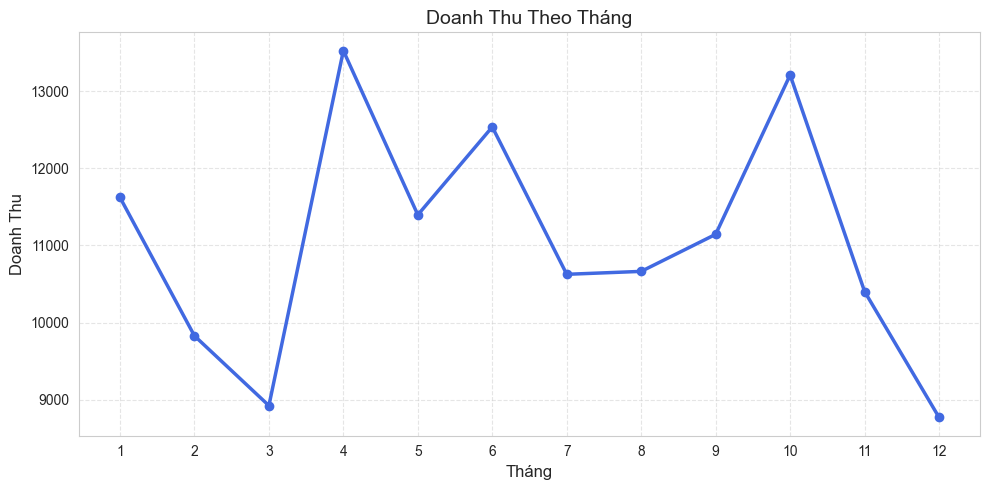

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(
    sales_by_month["Month"],
    sales_by_month["Sales"],
    marker="o",
    linewidth=2.5,
    color="royalblue"
)

plt.title("Doanh Thu Theo Tháng", fontsize=14)
plt.xlabel("Tháng", fontsize=12)
plt.ylabel("Doanh Thu", fontsize=12)
plt.xticks(sales_by_month["Month"])
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Chart 2: Doanh Thu Theo Khu Vực

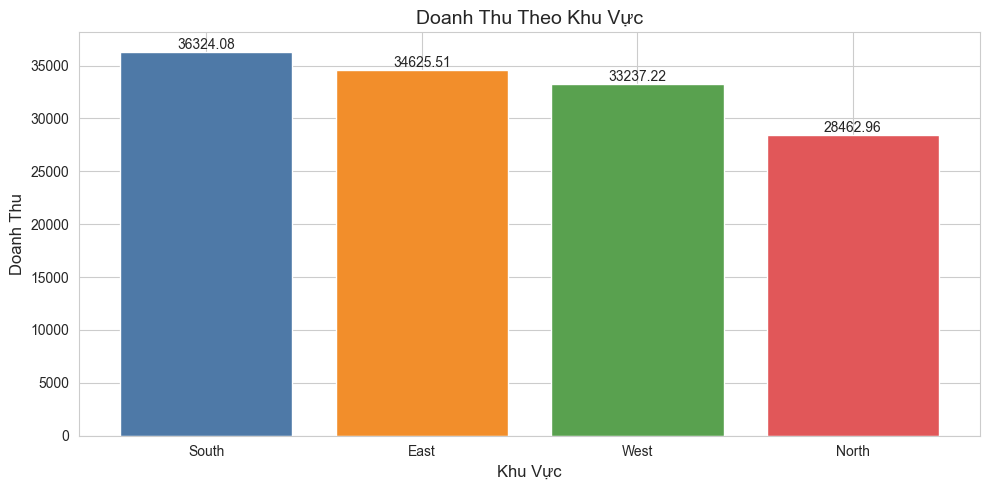

In [5]:
plt.figure(figsize=(10, 5))
bars = plt.bar(
    sales_by_region["Region"],
    sales_by_region["Sales"],
    color=["#4E79A7", "#F28E2B", "#59A14F", "#E15759"]
)

plt.title("Doanh Thu Theo Khu Vực", fontsize=14)
plt.xlabel("Khu Vực", fontsize=12)
plt.ylabel("Doanh Thu", fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## Chart 3: Tỷ Lệ Doanh Thu Theo Category

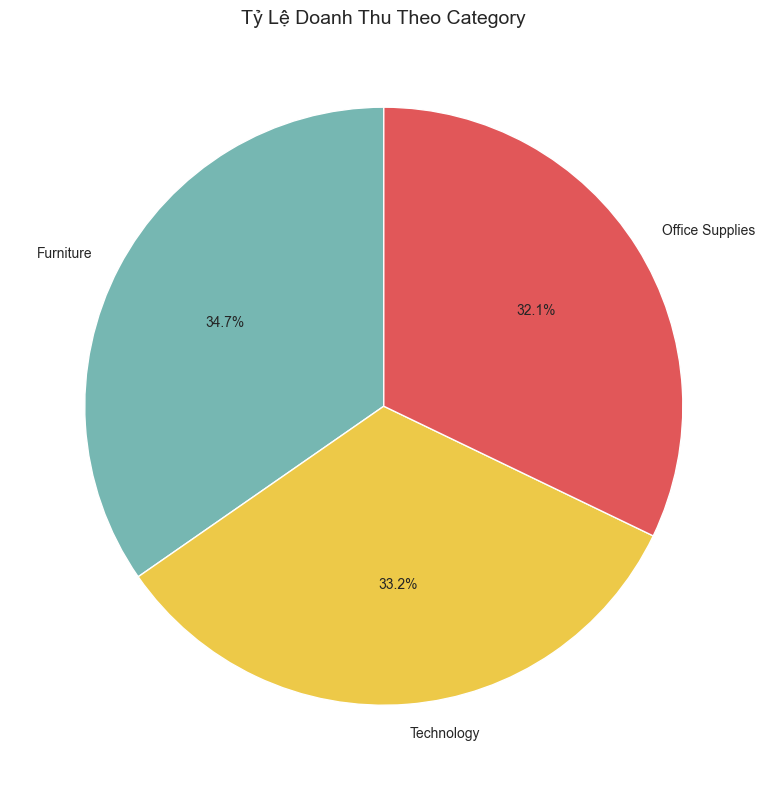

In [6]:
plt.figure(figsize=(8, 8))
plt.pie(
    sales_by_category["Sales"],
    labels=sales_by_category["Category"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#76B7B2", "#EDC948", "#E15759"]
)

plt.title("Tỷ Lệ Doanh Thu Theo Category", fontsize=14)
plt.tight_layout()
plt.show()

## Chart 4: Mối Quan Hệ Giữa Sales và Profit

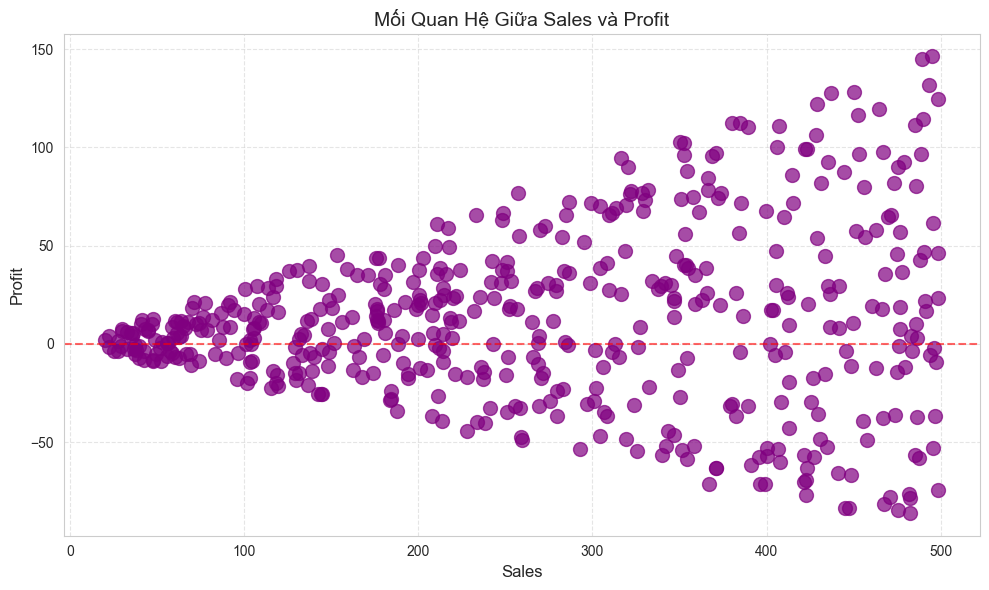

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df["Sales"],
    df["Profit"],
    color="purple",
    s=100,
    alpha=0.7
)

plt.title("Mối Quan Hệ Giữa Sales và Profit", fontsize=14)
plt.xlabel("Sales", fontsize=12)
plt.ylabel("Profit", fontsize=12)
plt.axhline(y=0, color="red", linestyle="--", alpha=0.6)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()